# Complex rules selected by atlas claims

In [1]:
import os
import sys
from dataclasses import replace

sys.path[:0] = [os.path.abspath("scripts"), os.path.abspath(".."), os.path.abspath("../differential_rules")]
import complex_investigation as ci
import complex_investigation_vis as vis
import complex_hypotheses as hypotheses
from IPython.display import display

In [2]:
CONFIG = ci.Config(
    max_items=4, support=0.01, expected_support=0.01, confidence=0.5,
    min_cells=20, min_fovs=5, min_patients=3, min_group_fovs=10,
    visible_gap=0.15, top_n=8, permutations=4999,
    score=os.environ.get("SCORE_COLUMN", "Clinical score"),
)
PREFIX = "paper_" + ("clin" if CONFIG.score.startswith("Clinical") else "path")

The atlas claims select these rules before ranking the mined results. Every hypothesis is shown, including absent rules; only interesting spatial results belong in the report. These three-type checks extend the paper's claims and are not exact replications.

In [3]:
SPECS = hypotheses.paper_specs()
display(SPECS[['organ', 'rule', 'claim']])

,organ,rule,claim
0,Colon,Plasma -> CD4T + Epithelial,Atlas Fig. 2I–K and supplementary Fig. S3I–J: ...
1,Colon,CD4T + Epithelial -> Plasma,Atlas Fig. 2I–K and supplementary Fig. S3I–J: ...
2,Duodenum,Plasma -> CD4T + Epithelial,Atlas Fig. 2I–K and supplementary Fig. S3I–J: ...
3,Duodenum,CD4T + Epithelial -> Plasma,Atlas Fig. 2I–K and supplementary Fig. S3I–J: ...
4,Colon,Goblet -> CD4T + Macrophage,Atlas Fig. 2D–F and supplementary Fig. S3H: CD...
5,Colon,CD4T + Macrophage -> Goblet,Atlas Fig. 2D–F and supplementary Fig. S3H: CD...
6,Duodenum,Goblet -> CD4T + Macrophage,Atlas Fig. 2D–F and supplementary Fig. S3H: CD...
7,Duodenum,CD4T + Macrophage -> Goblet,Atlas Fig. 2D–F and supplementary Fig. S3H: CD...
8,Duodenum,Endocrine -> Epithelial + Muscle,Atlas Fig. 3I–K: endocrine cells localize clos...
9,Duodenum,Epithelial + Muscle -> Endocrine,Atlas Fig. 3I–K: endocrine cells localize clos...


[C] marks the center; every other item is a neighbor. Rules retain their stored mining FDR and classification. Attraction requires the displayed observed support and confidence; avoidance uses expected support = Support − Leverage, including Lift = 0. Eligibility requires every named type in the FOV.

Stage tests reuse the differential permutation methods (fixed seed 0): FOV occurrence, biopsy mean, and patient mean of biopsy means. Cross-stage patients are omitted only from unpaired patient tests, never from plots. BH correction covers both organs, both rule states and all three contrasts plus the ordered trend within each analysis and unit. These exploratory screens are not independent validation. Patient FDR is evidence, not a mandatory display gate.

In [4]:
cells, metadata, rules = ci.load(CONFIG)
analysis = ci.analyse(rules, cells, metadata, CONFIG,
                      extra=hypotheses.extra_definitions(SPECS))
ci.save_tables(analysis, SPECS, PREFIX)

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv + results_CN_complex.csv
{'max_items': 4, 'min_cells': 20, 'mining_fdr': 0.05, 'support': 0.01, 'confidence': 0.5, 'expected_support': 0.01, 'score': 'Clinical score', 'min_fovs': 5, 'min_patients': 3, 'min_group_fovs': 10, 'visible_gap': 0.15, 'attraction_lift_gap': 0.3, 'avoidance_lift_gap': 0.15, 'permutations': 4999, 'top_n': 8}
690,345 stored center-specific occurrences; distinct cell types only
Mining settings: {'settings': {'weighting': 'binary', 'method': 'CN', 'radius': 25.0, 'min_support': 0.01, 'min_lift': 1.2, 'max_items_per_rule': 4, 'bandwidth': 15.0, 'k_neighbors': None, 'min_cells_per_patch': 2, 'max_one_type_share': 0.9, 'min_patches': 15, 'strong_confidence': 0.9, 'min_support_when_strong': 0.005, 'min_confidence': 0.5, 'min_leverage': 0.0005, 'min_conviction': 1.3, 'include_avoidance_rules': True, 'avoidance_max_lift': 0.8, 'avoidance_max_leverage': None

In [5]:
def show_selected(index):
    vis.show_selected(index, SPECS, analysis, rules, cells, metadata, PREFIX)

**[0] Colon · Plasma -> CD4T + Epithelial**

Atlas Fig. 2I–K and supplementary Fig. S3I–J: plasma cells and CD4 T cells occupy reproducible zones near the epithelium; test the plasma-centered epithelial/CD4 neighborhood across stages.

The atlas did not test this three-item ARM rule; this is a claim-driven spatial extension, not proof of cell loss.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,7,52,97,5,15
1,All,avoids,1,52,97,1,15
2,Control,attracts,5,25,25,3,4
3,Control,avoids,0,25,25,0,4
4,Mild,attracts,0,3,18,0,2
5,Mild,avoids,0,3,18,0,2
6,Severe,attracts,2,24,54,2,9
7,Severe,avoids,1,24,54,1,9


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_eb81d64231_summary.pdf


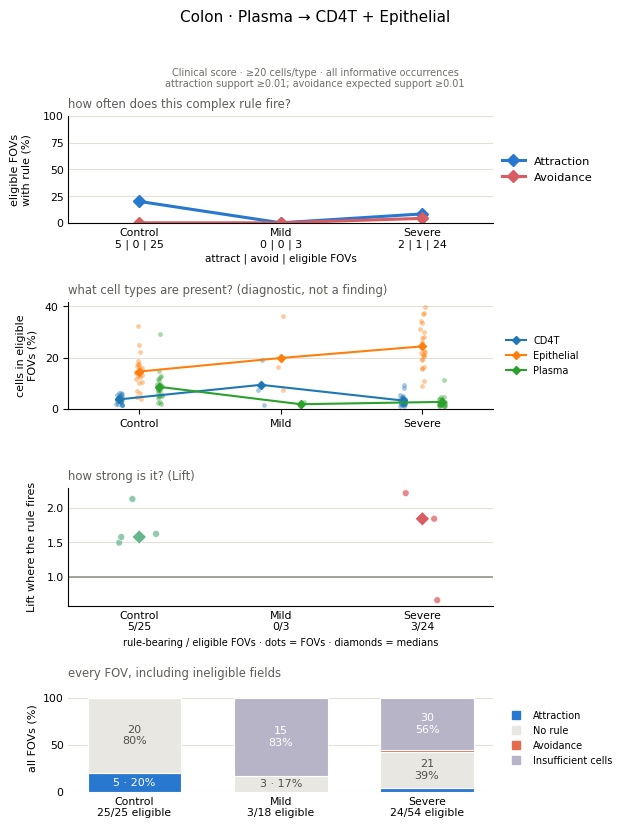

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_eb81d64231_parent_prevalence.pdf


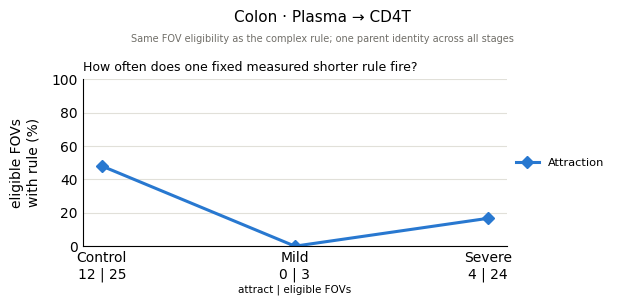

Fixed parent: Plasma -> CD4T; most often the best measured shorter rule in 6 matched FOVs.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_eb81d64231_fovs_rules.pdf


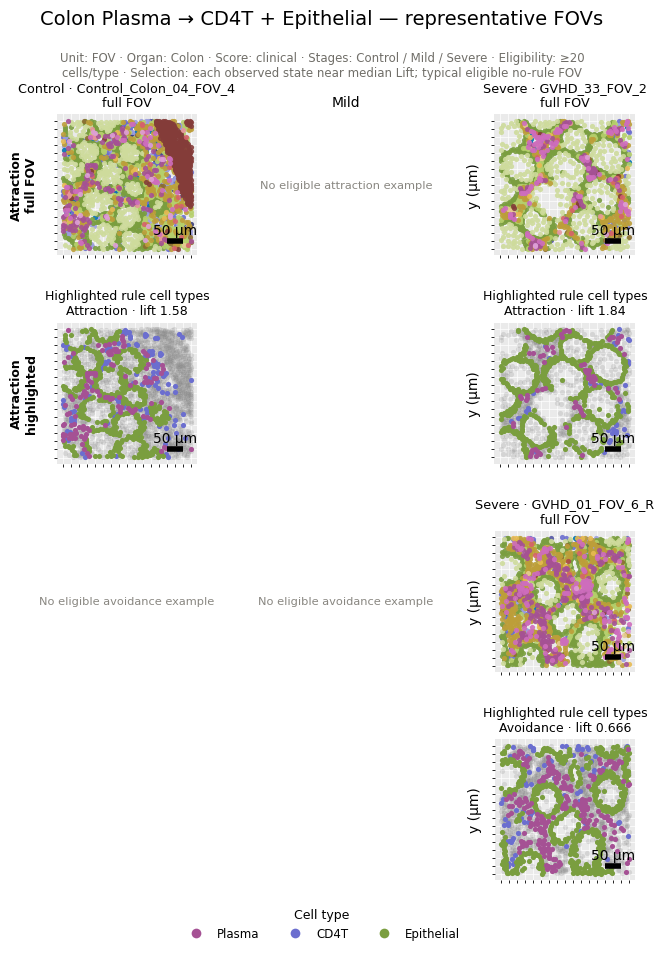

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_eb81d64231_fovs_no_rule.pdf


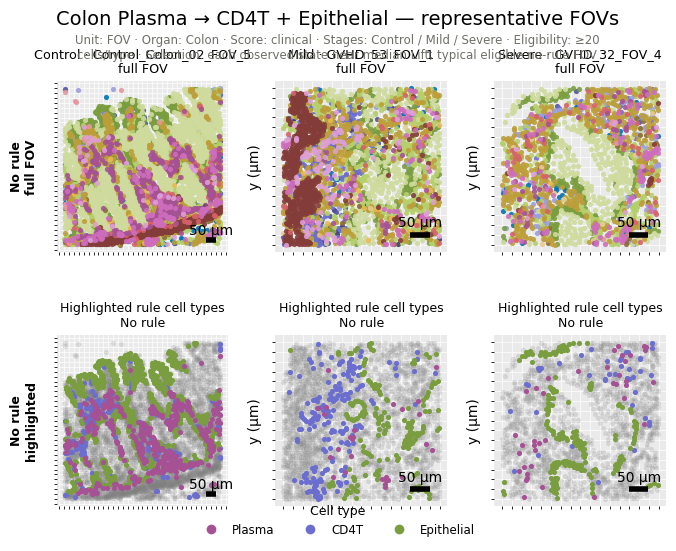

In [6]:
show_selected(0)

**[1] Colon · CD4T + Epithelial -> Plasma**

Atlas Fig. 2I–K and supplementary Fig. S3I–J: plasma cells and CD4 T cells occupy reproducible zones near the epithelium; test the plasma-centered epithelial/CD4 neighborhood across stages.

The atlas did not test this three-item ARM rule; this is a claim-driven spatial extension, not proof of cell loss.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,10,52,97,6,15
1,All,avoids,1,52,97,1,15
2,Control,attracts,8,25,25,4,4
3,Control,avoids,0,25,25,0,4
4,Mild,attracts,0,3,18,0,2
5,Mild,avoids,0,3,18,0,2
6,Severe,attracts,2,24,54,2,9
7,Severe,avoids,1,24,54,1,9


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_7931d2ebdd_summary.pdf


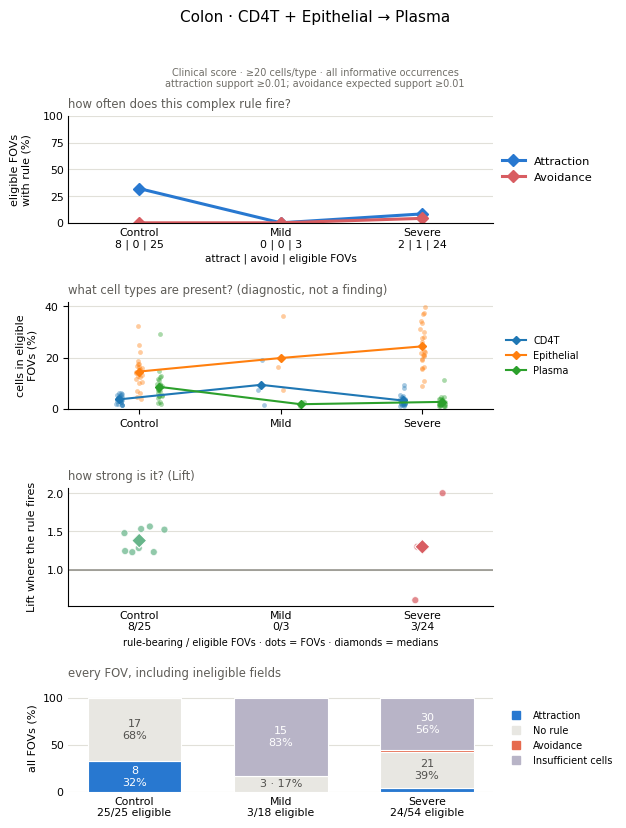

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_7931d2ebdd_parent_prevalence.pdf


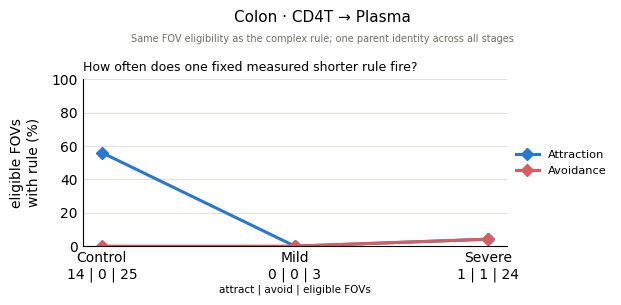

Fixed parent: CD4T -> Plasma; most often the best measured shorter rule in 4 matched FOVs.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_7931d2ebdd_fovs_rules.pdf


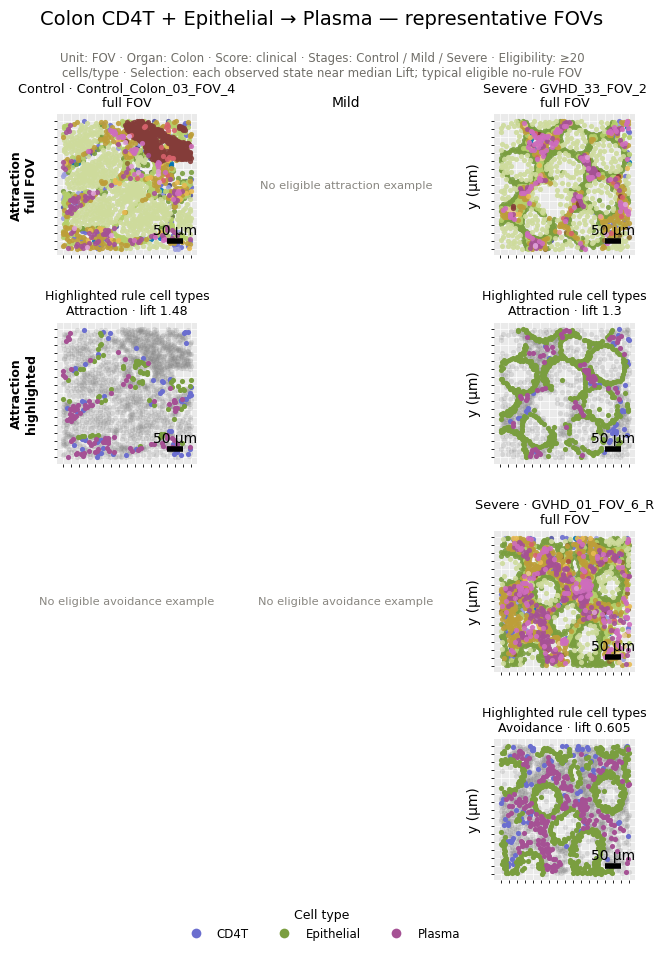

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_7931d2ebdd_fovs_no_rule.pdf


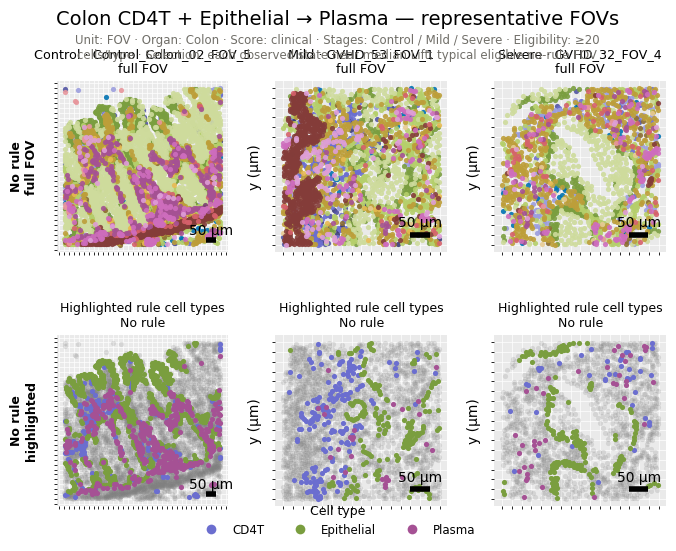

In [7]:
show_selected(1)

**[2] Duodenum · Plasma -> CD4T + Epithelial**

Atlas Fig. 2I–K and supplementary Fig. S3I–J: plasma cells and CD4 T cells occupy reproducible zones near the epithelium; test the plasma-centered epithelial/CD4 neighborhood across stages.

The atlas did not test this three-item ARM rule; this is a claim-driven spatial extension, not proof of cell loss.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,24,127,170,15,45
1,All,avoids,0,127,170,0,45
2,Control,attracts,5,30,31,4,10
3,Control,avoids,0,30,31,0,10
4,Mild,attracts,18,71,98,10,24
5,Mild,avoids,0,71,98,0,24
6,Severe,attracts,1,26,41,1,11
7,Severe,avoids,0,26,41,0,11


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_4962e5730d_summary.pdf


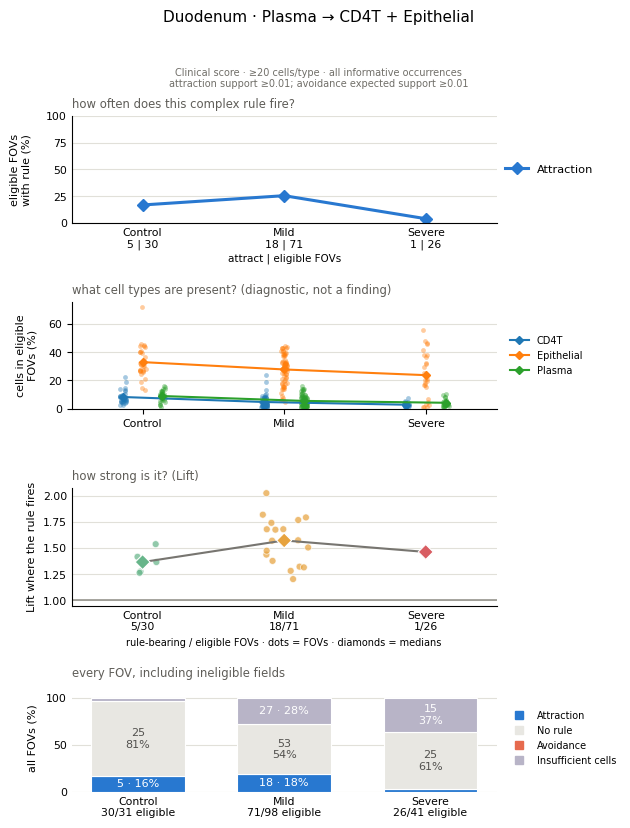

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_4962e5730d_parent_prevalence.pdf


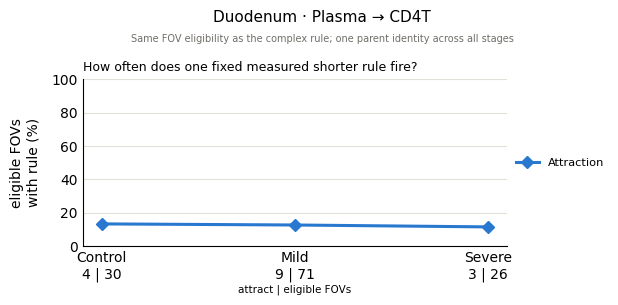

Fixed parent: Plasma -> CD4T; most often the best measured shorter rule in 13 matched FOVs.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_4962e5730d_fovs.pdf


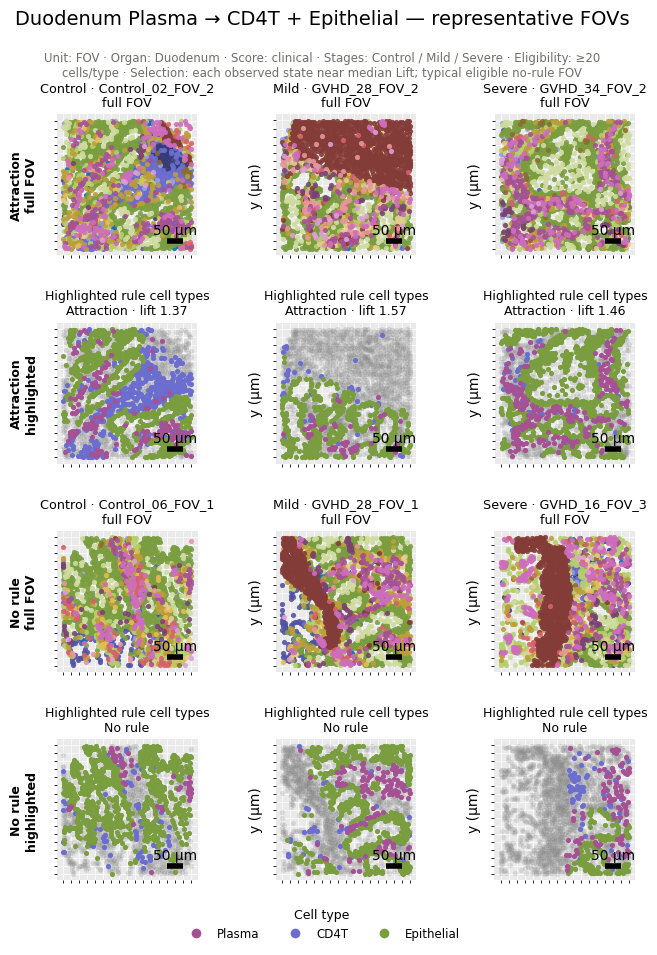

In [8]:
show_selected(2)

**[3] Duodenum · CD4T + Epithelial -> Plasma**

Atlas Fig. 2I–K and supplementary Fig. S3I–J: plasma cells and CD4 T cells occupy reproducible zones near the epithelium; test the plasma-centered epithelial/CD4 neighborhood across stages.

The atlas did not test this three-item ARM rule; this is a claim-driven spatial extension, not proof of cell loss.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,19,127,170,15,45
1,All,avoids,0,127,170,0,45
2,Control,attracts,3,30,31,3,10
3,Control,avoids,0,30,31,0,10
4,Mild,attracts,12,71,98,9,24
5,Mild,avoids,0,71,98,0,24
6,Severe,attracts,4,26,41,3,11
7,Severe,avoids,0,26,41,0,11


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_c93563e07a_summary.pdf


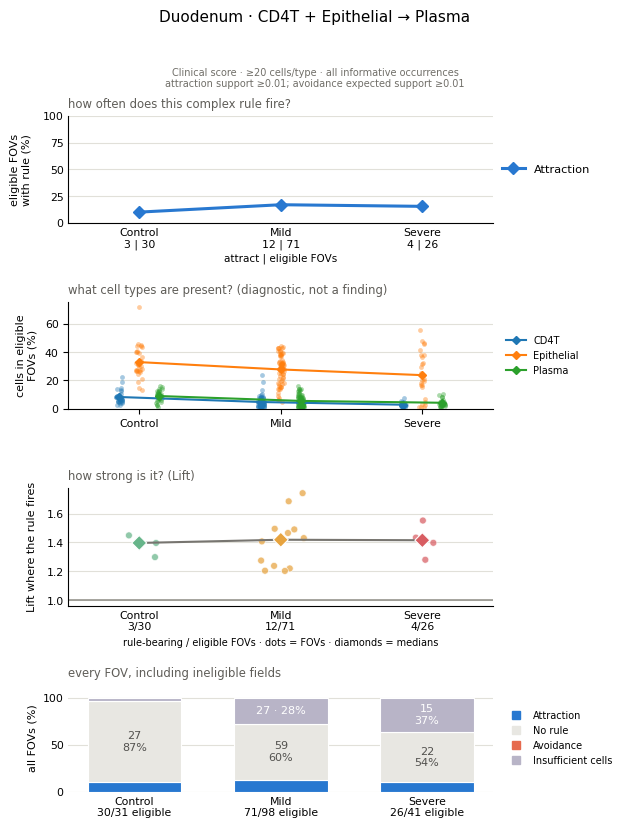

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_c93563e07a_parent_prevalence.pdf


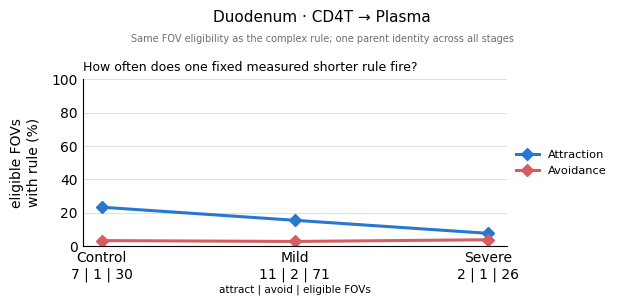

Fixed parent: CD4T -> Plasma; most often the best measured shorter rule in 5 matched FOVs.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_c93563e07a_fovs.pdf


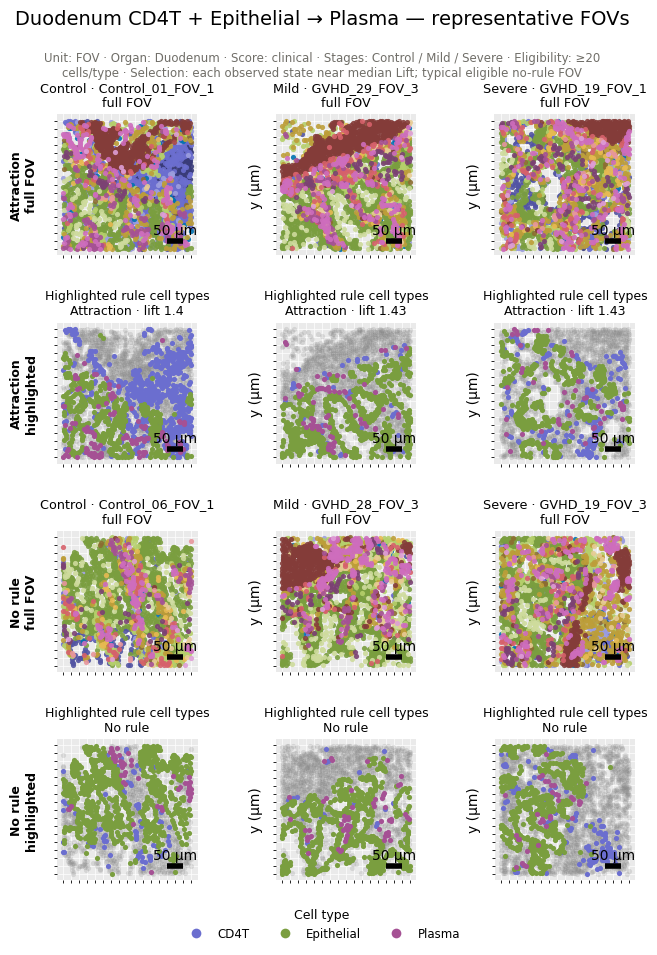

In [9]:
show_selected(3)

**[4] Colon · Goblet -> CD4T + Macrophage**

Atlas Fig. 2D–F and supplementary Fig. S3H: CD4 T cells and macrophages favor lamina propria over epithelium; test goblet-centered exclusion of their joint neighborhood across stages.

The paper does not claim this exact joint avoidance; broad spatial alignment only.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,71,97,0,18
1,All,avoids,56,71,97,16,18
2,Control,attracts,0,25,25,0,4
3,Control,avoids,25,25,25,4,4
4,Mild,attracts,0,9,18,0,3
5,Mild,avoids,4,9,18,2,3
6,Severe,attracts,0,37,54,0,11
7,Severe,avoids,27,37,54,10,11


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_5cb52cff60_summary.pdf


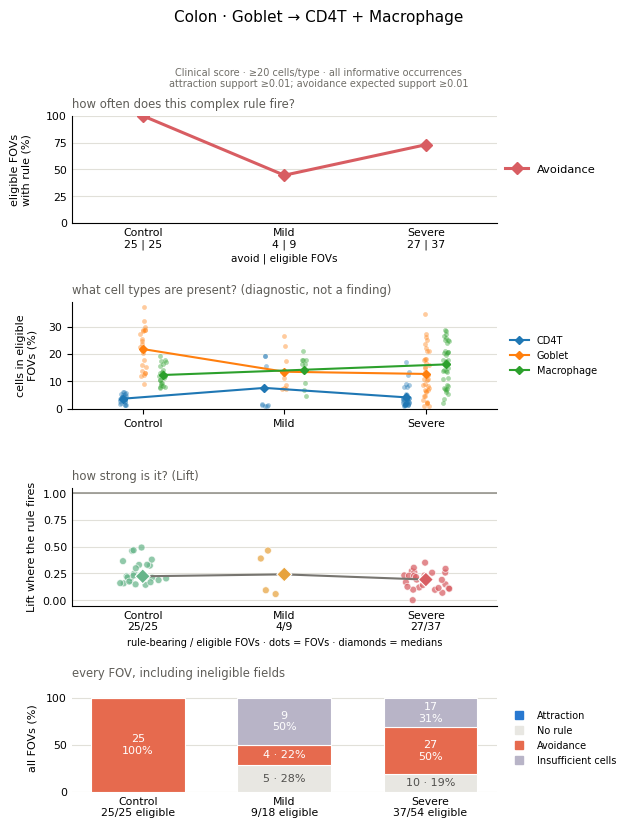

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_5cb52cff60_parent_prevalence.pdf


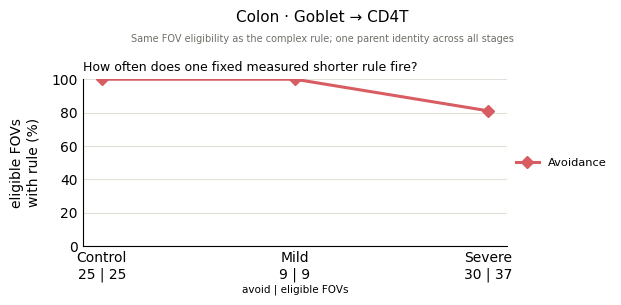

Fixed parent: Goblet -> CD4T; most often the best measured shorter rule in 52 matched FOVs.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_5cb52cff60_fovs.pdf


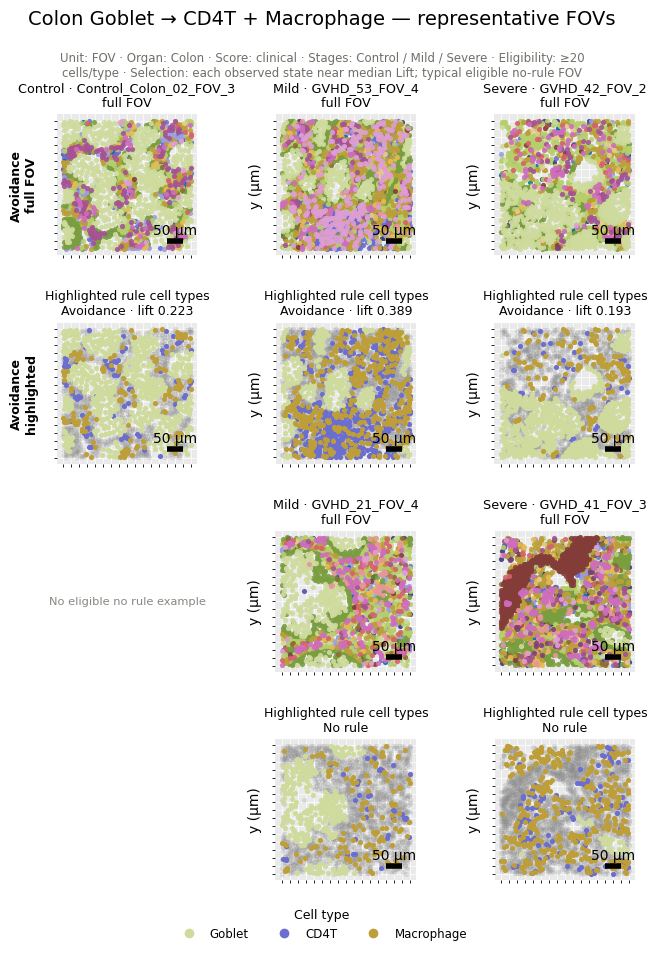

In [10]:
show_selected(4)

**[5] Colon · CD4T + Macrophage -> Goblet**

Atlas Fig. 2D–F and supplementary Fig. S3H: CD4 T cells and macrophages favor lamina propria over epithelium; test goblet-centered exclusion of their joint neighborhood across stages.

The paper does not claim this exact joint avoidance; broad spatial alignment only.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,71,97,0,18
1,All,avoids,31,71,97,15,18
2,Control,attracts,0,25,25,0,4
3,Control,avoids,13,25,25,4,4
4,Mild,attracts,0,9,18,0,3
5,Mild,avoids,1,9,18,1,3
6,Severe,attracts,0,37,54,0,11
7,Severe,avoids,17,37,54,10,11


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_37a8193a41_summary.pdf


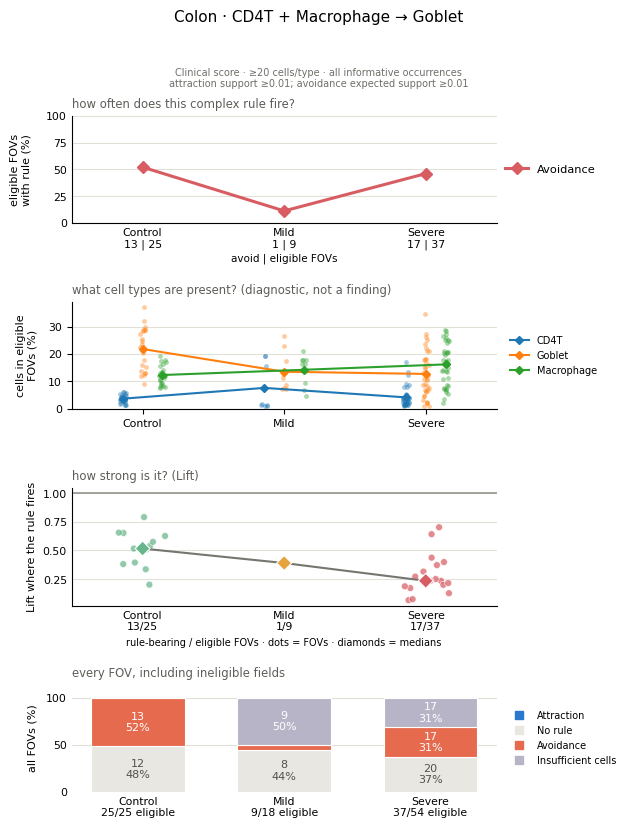

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_37a8193a41_parent_prevalence.pdf


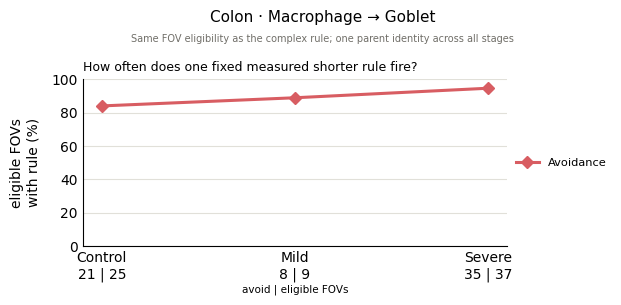

Fixed parent: Macrophage -> Goblet; most often the best measured shorter rule in 24 matched FOVs.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Colon_37a8193a41_fovs.pdf


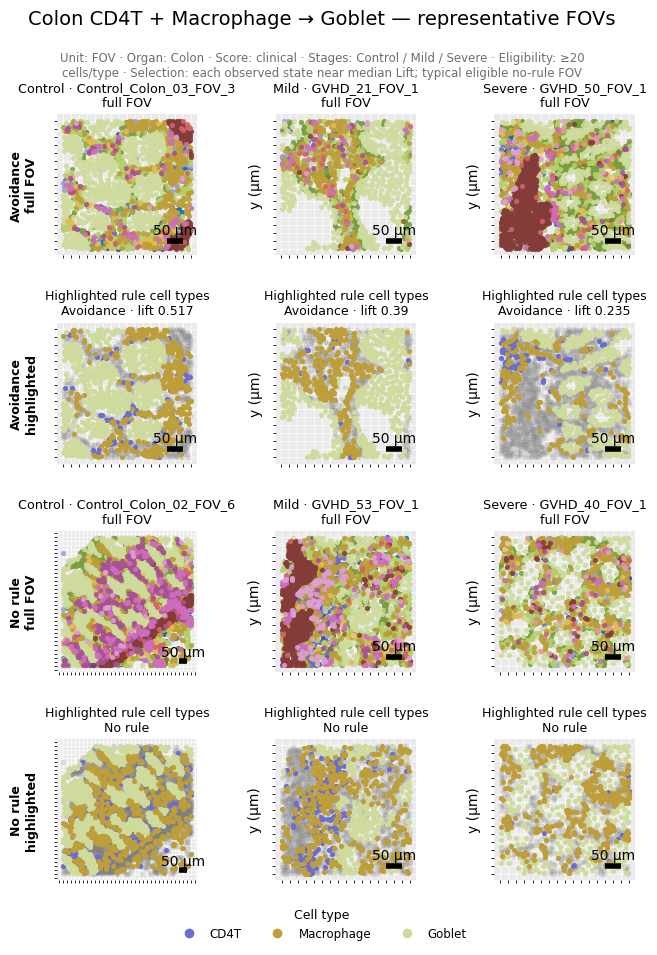

In [11]:
show_selected(5)

**[6] Duodenum · Goblet -> CD4T + Macrophage**

Atlas Fig. 2D–F and supplementary Fig. S3H: CD4 T cells and macrophages favor lamina propria over epithelium; test goblet-centered exclusion of their joint neighborhood across stages.

The paper does not claim this exact joint avoidance; broad spatial alignment only.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,126,170,0,41
1,All,avoids,75,126,170,32,41
2,Control,attracts,0,30,31,0,10
3,Control,avoids,20,30,31,10,10
4,Mild,attracts,0,75,98,0,24
5,Mild,avoids,48,75,98,18,24
6,Severe,attracts,0,21,41,0,7
7,Severe,avoids,7,21,41,4,7


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_2458d5c779_summary.pdf


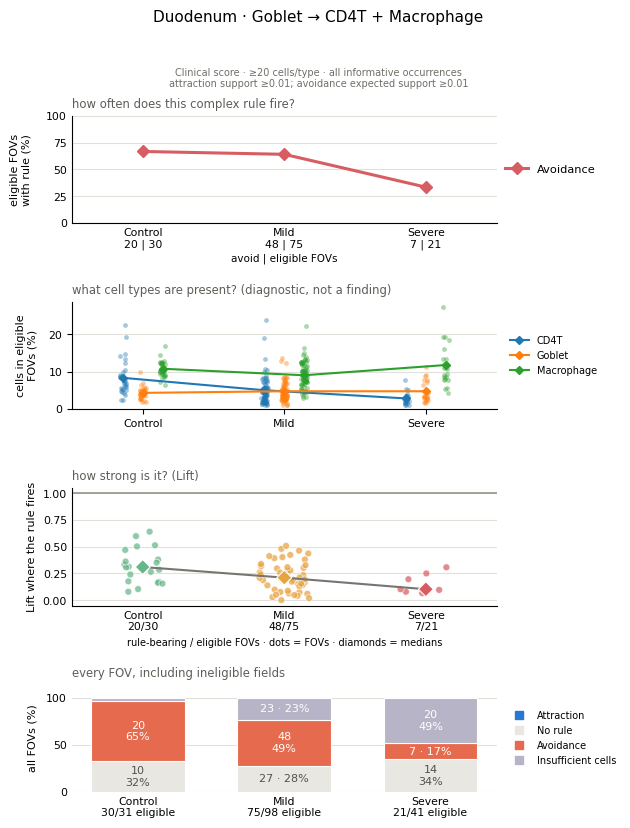

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_2458d5c779_parent_prevalence.pdf


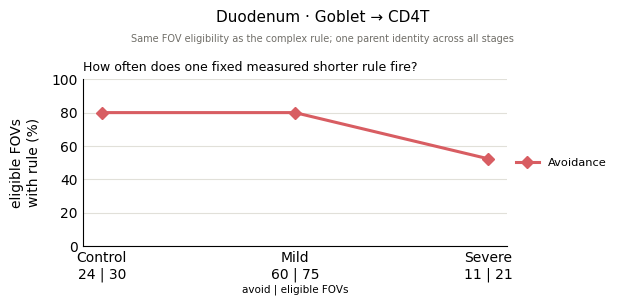

Fixed parent: Goblet -> CD4T; most often the best measured shorter rule in 50 matched FOVs.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_2458d5c779_fovs.pdf


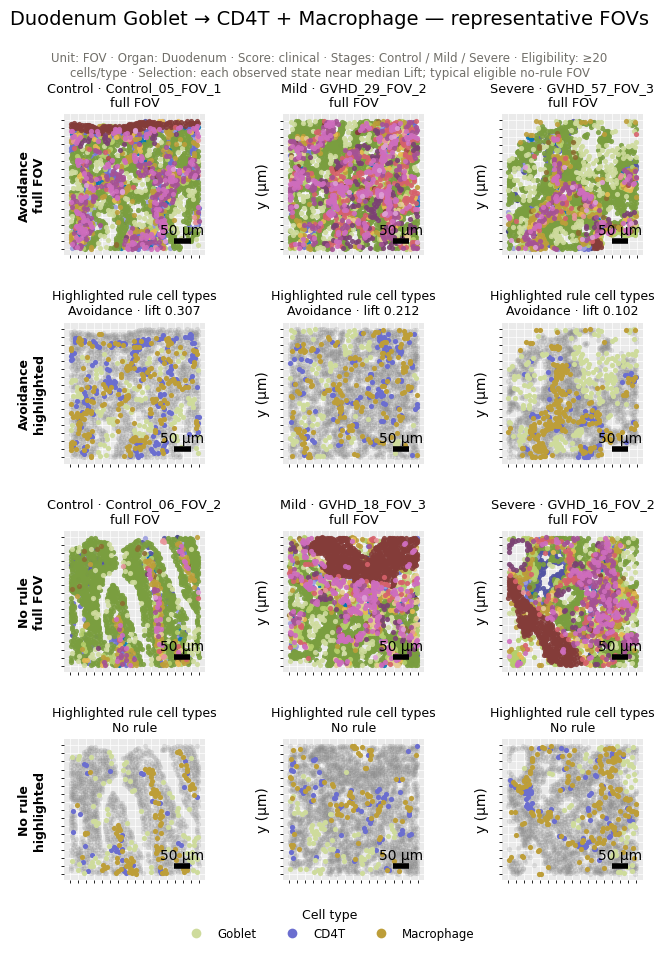

In [12]:
show_selected(6)

**[7] Duodenum · CD4T + Macrophage -> Goblet**

Atlas Fig. 2D–F and supplementary Fig. S3H: CD4 T cells and macrophages favor lamina propria over epithelium; test goblet-centered exclusion of their joint neighborhood across stages.

The paper does not claim this exact joint avoidance; broad spatial alignment only.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,126,170,0,41
1,All,avoids,51,126,170,29,41
2,Control,attracts,0,30,31,0,10
3,Control,avoids,9,30,31,6,10
4,Mild,attracts,0,75,98,0,24
5,Mild,avoids,32,75,98,19,24
6,Severe,attracts,0,21,41,0,7
7,Severe,avoids,10,21,41,4,7


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_460648422d_summary.pdf


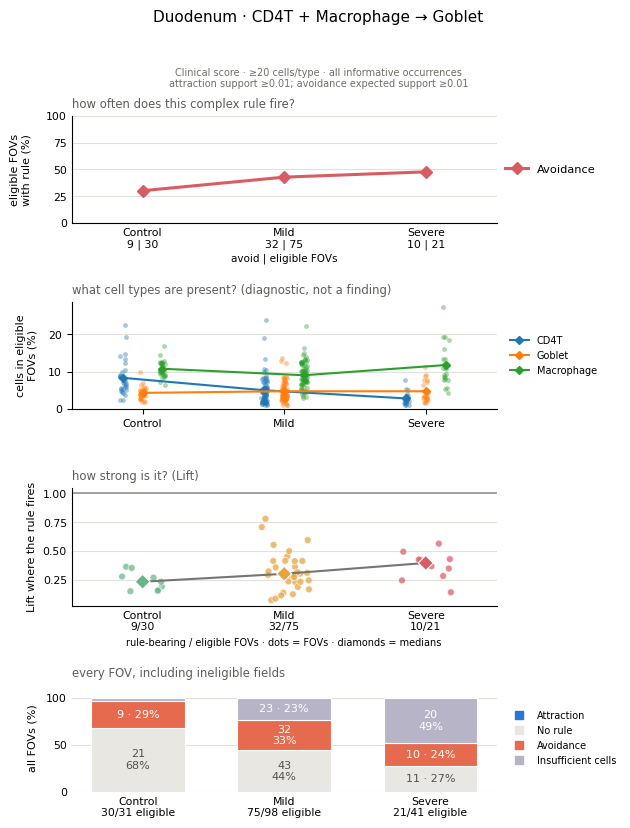

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_460648422d_parent_prevalence.pdf


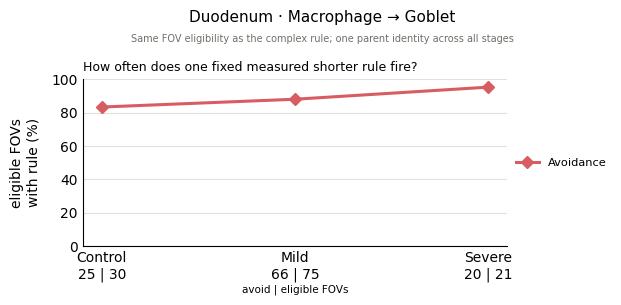

Fixed parent: Macrophage -> Goblet; most often the best measured shorter rule in 33 matched FOVs.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_460648422d_fovs.pdf


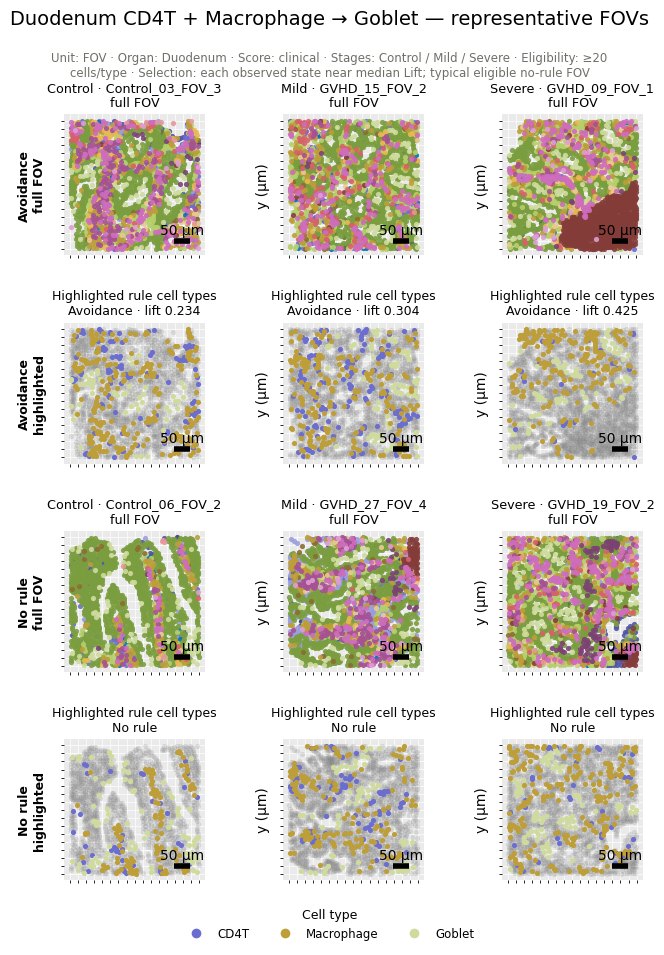

In [13]:
show_selected(7)

**[8] Duodenum · Endocrine -> Epithelial + Muscle**

Atlas Fig. 3I–K: endocrine cells localize closer to muscularis mucosa after transplantation; test the muscle-adjacent epithelial niche.

Local association cannot establish endocrine-cell replacement or differentiation.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,25,170,0,13
1,All,avoids,0,25,170,0,13
2,Control,attracts,0,0,31,0,0
3,Control,avoids,0,0,31,0,0
4,Mild,attracts,0,18,98,0,11
5,Mild,avoids,0,18,98,0,11
6,Severe,attracts,0,7,41,0,2
7,Severe,avoids,0,7,41,0,2


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_01ccfdbca9_summary.pdf


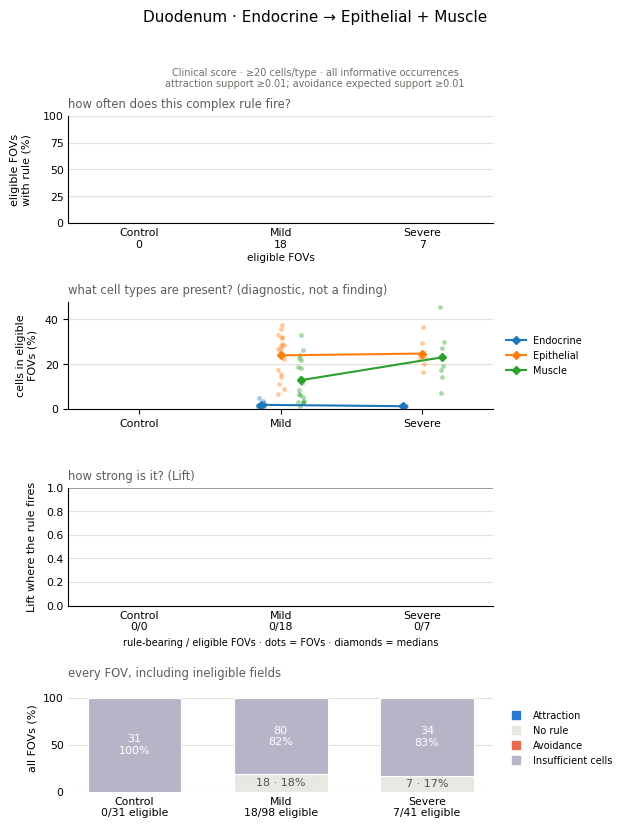

No measured shorter rule for a prevalence comparison.
No representative FOVs to plot.


In [14]:
show_selected(8)

**[9] Duodenum · Epithelial + Muscle -> Endocrine**

Atlas Fig. 3I–K: endocrine cells localize closer to muscularis mucosa after transplantation; test the muscle-adjacent epithelial niche.

Local association cannot establish endocrine-cell replacement or differentiation.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,4,25,170,2,13
1,All,avoids,0,25,170,0,13
2,Control,attracts,0,0,31,0,0
3,Control,avoids,0,0,31,0,0
4,Mild,attracts,1,18,98,1,11
5,Mild,avoids,0,18,98,0,11
6,Severe,attracts,3,7,41,1,2
7,Severe,avoids,0,7,41,0,2


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_c9f7b79238_summary.pdf


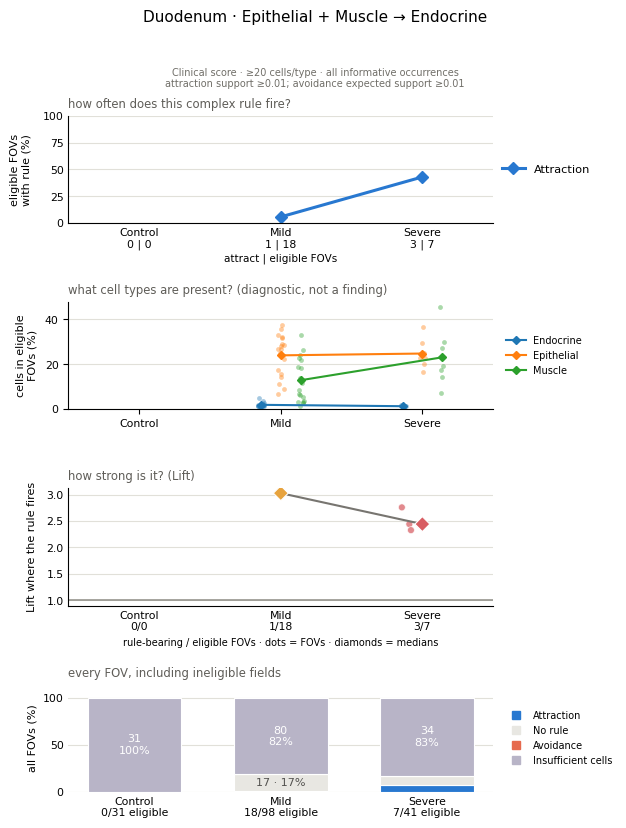

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_c9f7b79238_parent_prevalence.pdf


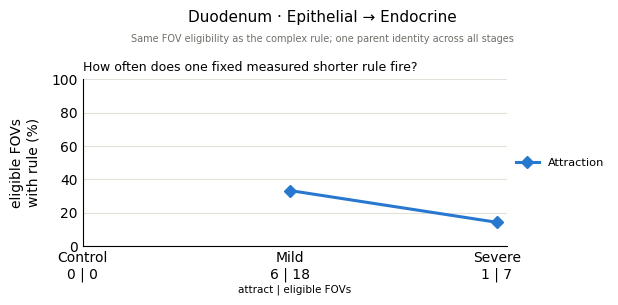

Fixed parent: Epithelial -> Endocrine; most often the best measured shorter rule in 1 matched FOVs.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_c9f7b79238_fovs.pdf


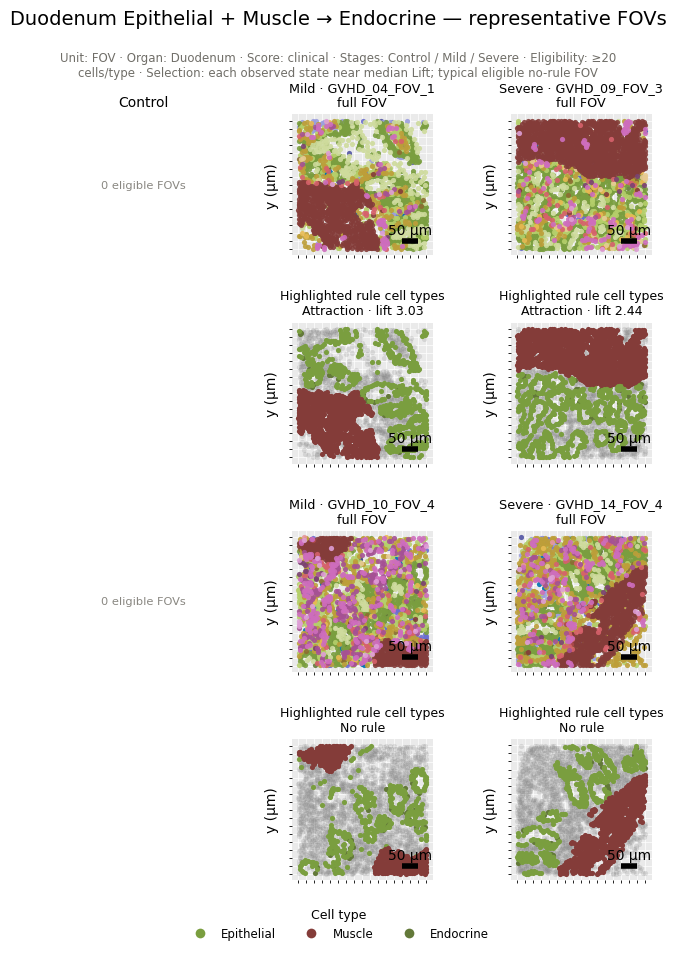

In [15]:
show_selected(9)

**[10] Duodenum · Paneth -> Epithelial + Muscle**

Atlas Fig. 2B and supplementary Fig. S5: Paneth cells occupy the crypt base near proliferative epithelium; test its muscle-adjacent organization.

Keep spatial organization separate from the uninteresting abundance-loss result; no stem-cell identity is measured.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,53,170,0,28
1,All,avoids,0,53,170,0,28
2,Control,attracts,0,8,31,0,7
3,Control,avoids,0,8,31,0,7
4,Mild,attracts,0,36,98,0,17
5,Mild,avoids,0,36,98,0,17
6,Severe,attracts,0,9,41,0,4
7,Severe,avoids,0,9,41,0,4


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_cae0bdf27d_summary.pdf


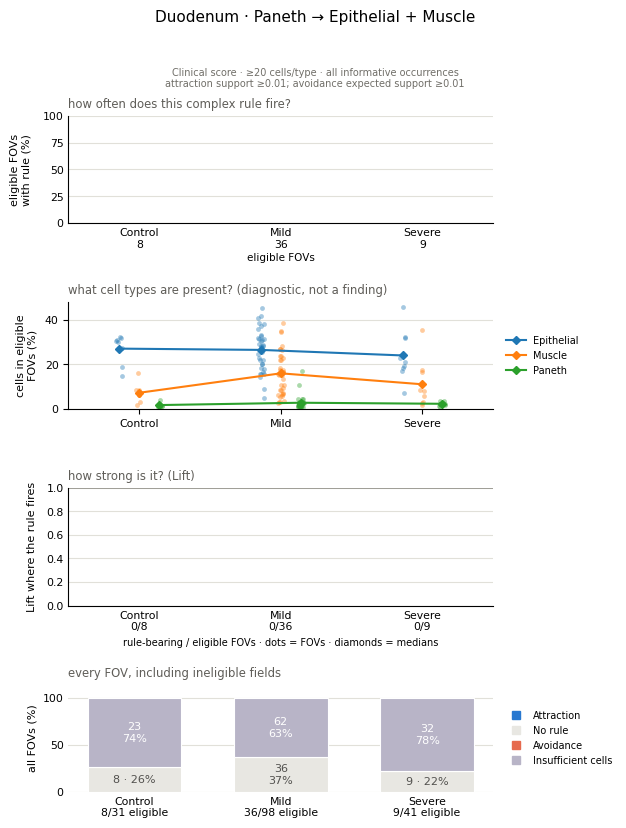

No measured shorter rule for a prevalence comparison.
No representative FOVs to plot.


In [16]:
show_selected(10)

**[11] Duodenum · Epithelial + Muscle -> Paneth**

Atlas Fig. 2B and supplementary Fig. S5: Paneth cells occupy the crypt base near proliferative epithelium; test its muscle-adjacent organization.

Keep spatial organization separate from the uninteresting abundance-loss result; no stem-cell identity is measured.

https://doi.org/10.1126/scitranslmed.adu6032

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,2,53,170,2,28
1,All,avoids,0,53,170,0,28
2,Control,attracts,0,8,31,0,7
3,Control,avoids,0,8,31,0,7
4,Mild,attracts,2,36,98,2,17
5,Mild,avoids,0,36,98,0,17
6,Severe,attracts,0,9,41,0,4
7,Severe,avoids,0,9,41,0,4


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_475570e3cf_summary.pdf


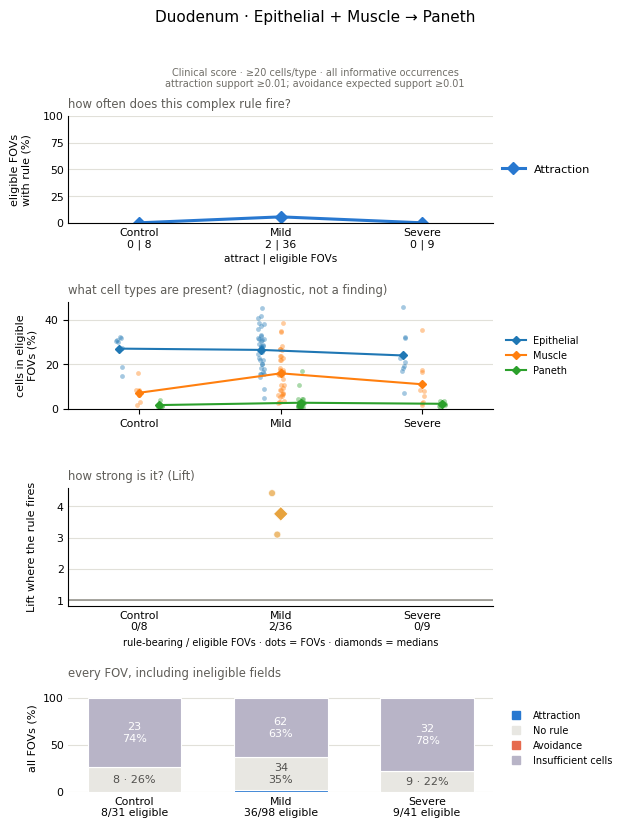

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_475570e3cf_parent_prevalence.pdf


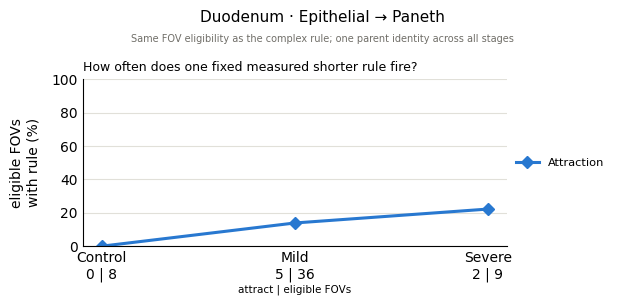

Fixed parent: Epithelial -> Paneth; most often the best measured shorter rule in 1 matched FOVs.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\paper_clin_Duodenum_475570e3cf_fovs.pdf


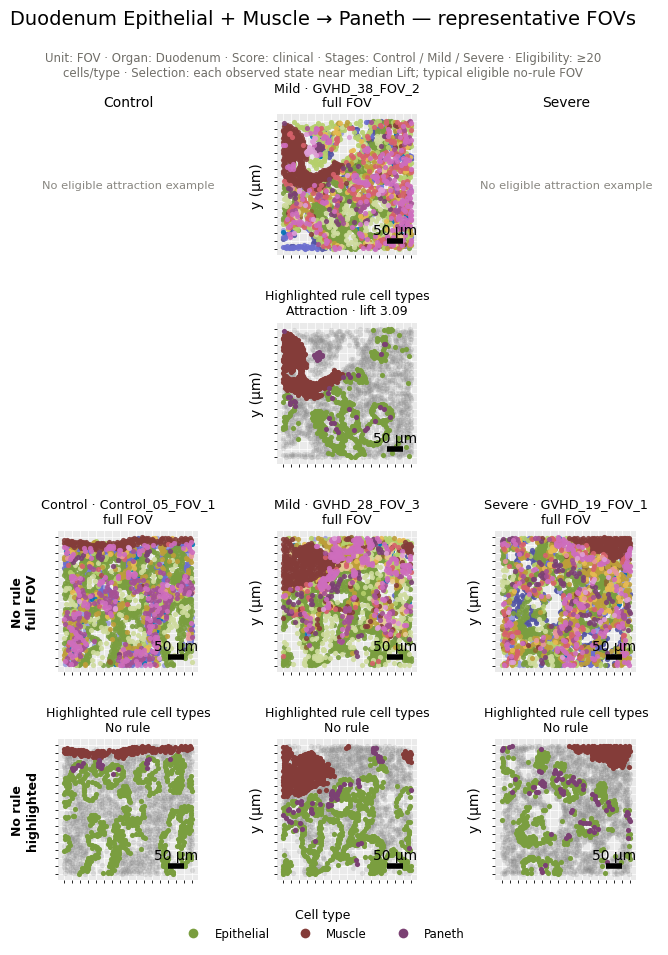

In [17]:
show_selected(11)